# WearGait EDA

Exploratory Data Analysis notebook for WearGait data used in the unimodal gait pipeline.

This notebook focuses on:
- File/task/subject inventory
- Label balance (PD vs HC)
- Channel availability and missingness
- Sampling/timing checks
- Quick signal visualization

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

In [2]:
# Paths
repo_root = Path('/ocean/projects/med260006p/shared/biomedAI/project/replica')
weargait_root = repo_root / 'data' / 'gait' / 'weargait'
index_csv = repo_root / 'outputs' / 'unimodal_gait' / 'weargait_index.csv'

print('WearGait root:', weargait_root)
print('Index CSV exists:', index_csv.exists(), index_csv)

WearGait root: /ocean/projects/med260006p/shared/biomedAI/project/replica/data/gait/weargait
Index CSV exists: True /ocean/projects/med260006p/shared/biomedAI/project/replica/outputs/unimodal_gait/weargait_index.csv


In [3]:
# Load indexed training subset if available; otherwise build lightweight inventory from files
if index_csv.exists():
    idx = pd.read_csv(index_csv)
else:
    rows = []
    for p in sorted(weargait_root.rglob('*.csv')):
        s = str(p)
        if 'CSV files' not in s:
            continue
        fname = p.name
        subject_id = fname.split('_', 1)[0]
        task = fname.rsplit('.', 1)[0].split('_', 1)[1] if '_' in fname else 'Unknown'
        label = 1 if 'PD PARTICIPANTS' in s.upper() else 0
        rows.append({'subject_id': subject_id, 'task': task, 'label': label, 'file_path': s})
    idx = pd.DataFrame(rows)

idx.head()

,subject_id,task,label,file_path
0,HC100,HurriedPace,0,/ocean/projects/med260006p/shared/biomedAI/pro...
1,HC100,SelfPace,0,/ocean/projects/med260006p/shared/biomedAI/pro...
2,HC100,TUG,0,/ocean/projects/med260006p/shared/biomedAI/pro...
3,HC101,HurriedPace,0,/ocean/projects/med260006p/shared/biomedAI/pro...
4,HC101,SelfPace,0,/ocean/projects/med260006p/shared/biomedAI/pro...


In [4]:
# High-level inventory
n_files = len(idx)
n_subjects = idx['subject_id'].nunique()
n_pd = idx.loc[idx['label'] == 1, 'subject_id'].nunique()
n_hc = idx.loc[idx['label'] == 0, 'subject_id'].nunique()

summary = pd.Series({
    'n_files': n_files,
    'n_subjects': n_subjects,
    'n_pd_subjects': n_pd,
    'n_hc_subjects': n_hc,
    'subject_ratio_pd_hc': (n_pd / n_hc) if n_hc else np.nan,
})
summary

n_files                554.000000
n_subjects             185.000000
n_pd_subjects          100.000000
n_hc_subjects           85.000000
subject_ratio_pd_hc      1.176471
dtype: float64

,n_files
task,
HurriedPace,185
SelfPace,185
TUG,184


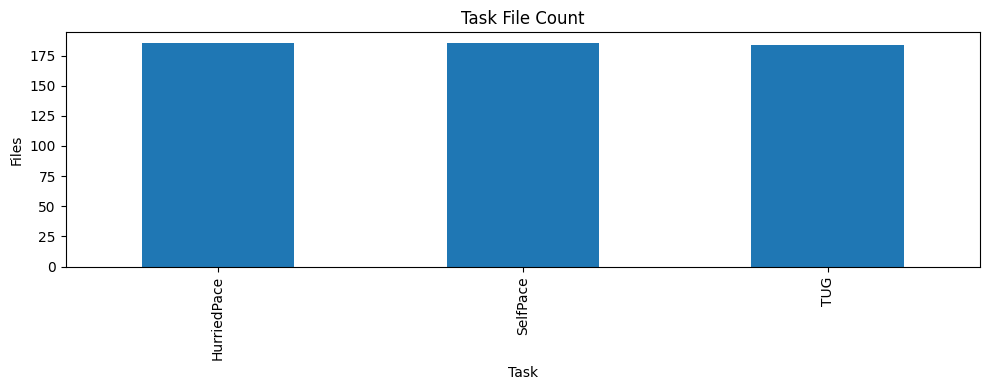

In [5]:
# Task distribution
task_counts = idx['task'].value_counts().sort_values(ascending=False)
display(task_counts.to_frame('n_files'))

ax = task_counts.plot(kind='bar', figsize=(10, 4), title='Task File Count')
ax.set_xlabel('Task')
ax.set_ylabel('Files')
plt.tight_layout()
plt.show()

In [6]:
# Subjects per task and label
subj_task = idx.groupby(['task', 'label'])['subject_id'].nunique().unstack(fill_value=0)
subj_task.columns = ['HC(0)' if c == 0 else 'PD(1)' for c in subj_task.columns]
subj_task

,HC(0),PD(1)
task,,
HurriedPace,85,100
SelfPace,85,100
TUG,85,99


In [7]:
# Core channels used by the training script
CHANNELS_V1 = [
    'LowerBack_Acc_X', 'LowerBack_Acc_Y', 'LowerBack_Acc_Z',
    'LowerBack_Gyr_X', 'LowerBack_Gyr_Y', 'LowerBack_Gyr_Z',
    'L_Ankle_Acc_X', 'L_Ankle_Acc_Y', 'L_Ankle_Acc_Z',
    'L_Ankle_Gyr_X', 'L_Ankle_Gyr_Y', 'L_Ankle_Gyr_Z',
    'R_Ankle_Acc_X', 'R_Ankle_Acc_Y', 'R_Ankle_Acc_Z',
    'R_Ankle_Gyr_X', 'R_Ankle_Gyr_Y', 'R_Ankle_Gyr_Z',
    'LTotalForce', 'RTotalForce', 'LCoP_X', 'LCoP_Y', 'RCoP_X', 'RCoP_Y',
]
len(CHANNELS_V1)

24

In [8]:
# Sample a subset of files for schema and missingness profiling
sample_n = min(40, len(idx))
sample_idx = idx.sample(sample_n, random_state=42).reset_index(drop=True)

schema_rows = []
for r in sample_idx.itertuples(index=False):
    p = Path(r.file_path)
    try:
        df = pd.read_csv(p, low_memory=False)
    except Exception:
        continue

    cols = set(df.columns)
    present = [c for c in CHANNELS_V1 if c in cols]
    missing = [c for c in CHANNELS_V1 if c not in cols]

    schema_rows.append({
        'file': p.name,
        'subject_id': r.subject_id,
        'task': r.task,
        'label': r.label,
        'n_rows': len(df),
        'n_cols': len(df.columns),
        'core_present': len(present),
        'core_missing': len(missing),
    })

schema_df = pd.DataFrame(schema_rows)
schema_df.head()

,file,subject_id,task,label,n_rows,n_cols,core_present,core_missing
0,HC128_TUG.csv,HC128,TUG,0,6247,347,24,0
1,HC128_HurriedPace.csv,HC128,HurriedPace,0,3083,347,24,0
2,NLS162_TUG.csv,NLS162,TUG,1,4575,297,18,6
3,WHC031_TUG.csv,WHC031,TUG,0,6371,347,24,0
4,NLS035_HurriedPace.csv,NLS035,HurriedPace,1,3082,347,24,0


,count,mean,std,min,25%,50%,75%,max
n_rows,40.0,5338.85,2286.856823,2213.0,4066.0,5070.5,6058.25,15333.0
n_cols,40.0,340.90,16.367259,297.0,347.0,347.0,347.00,347.0
core_present,40.0,23.40,1.822931,18.0,24.0,24.0,24.00,24.0
core_missing,40.0,0.60,1.822931,0.0,0.0,0.0,0.00,6.0


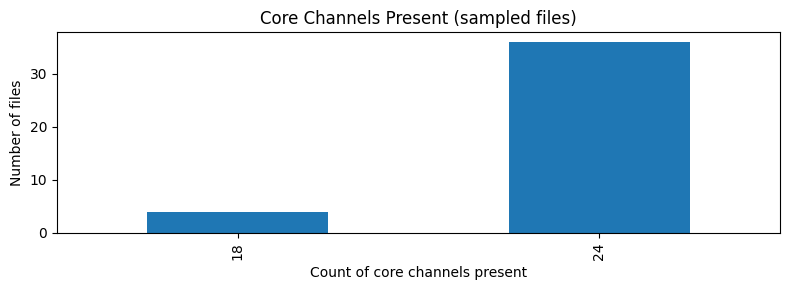

In [9]:
# Schema summary on sampled files
display(schema_df[['n_rows', 'n_cols', 'core_present', 'core_missing']].describe().T)

ax = schema_df['core_present'].value_counts().sort_index().plot(kind='bar', figsize=(8, 3), title='Core Channels Present (sampled files)')
ax.set_xlabel('Count of core channels present')
ax.set_ylabel('Number of files')
plt.tight_layout()
plt.show()

,mean_na_ratio
RCoP_Y,0.170491
RCoP_X,0.170491
RTotalForce,0.170491
LCoP_Y,0.170109
LCoP_X,0.170109
LTotalForce,0.170109
LowerBack_Acc_Y,0.000000
R_Ankle_Gyr_Z,0.000000
R_Ankle_Gyr_Y,0.000000
R_Ankle_Gyr_X,0.000000


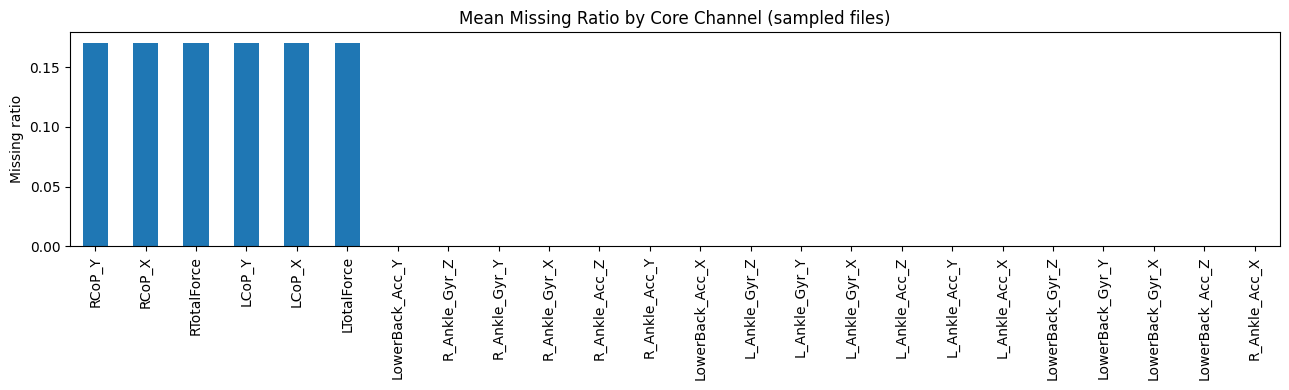

In [10]:
# Per-channel missingness on sampled files
miss_accum = []
for r in sample_idx.itertuples(index=False):
    p = Path(r.file_path)
    try:
        df = pd.read_csv(p, low_memory=False)
    except Exception:
        continue

    row = {'file': p.name}
    for c in CHANNELS_V1:
        if c in df.columns:
            vals = pd.to_numeric(df[c], errors='coerce')
            row[c] = float(vals.isna().mean())
        else:
            row[c] = 1.0
    miss_accum.append(row)

miss_df = pd.DataFrame(miss_accum)
mean_missing = miss_df.drop(columns=['file']).mean().sort_values(ascending=False)
display(mean_missing.to_frame('mean_na_ratio').head(24))

ax = mean_missing.plot(kind='bar', figsize=(13, 4), title='Mean Missing Ratio by Core Channel (sampled files)')
ax.set_ylabel('Missing ratio')
plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
median_dt,40.0,0.01,0.000000e+00,0.01,0.01,0.01,0.01,0.01
hz,40.0,100.00,5.756757e-14,100.00,100.00,100.00,100.00,100.00


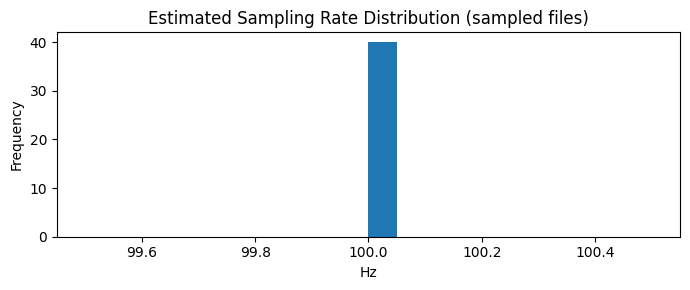

In [11]:
# Sampling rate / time increment check on sampled files
time_rows = []
for r in sample_idx.itertuples(index=False):
    p = Path(r.file_path)
    try:
        df = pd.read_csv(p, low_memory=False, usecols=lambda c: c == 'Time')
        if 'Time' not in df.columns:
            continue
        t = pd.to_numeric(df['Time'].astype(str).str.replace('sec', '', regex=False).str.strip(), errors='coerce')
        dt = t.diff().dropna()
        dt = dt[dt > 0]
        if len(dt) == 0:
            continue
        median_dt = float(dt.median())
        hz = 1.0 / median_dt if median_dt > 0 else np.nan
        time_rows.append({'file': p.name, 'subject_id': r.subject_id, 'task': r.task, 'median_dt': median_dt, 'hz': hz})
    except Exception:
        continue

time_df = pd.DataFrame(time_rows)
display(time_df[['median_dt', 'hz']].describe().T)

ax = time_df['hz'].plot(kind='hist', bins=20, figsize=(7, 3), title='Estimated Sampling Rate Distribution (sampled files)')
ax.set_xlabel('Hz')
plt.tight_layout()
plt.show()

Example file: HC100_HurriedPace.csv
Subject: HC100 | Task: HurriedPace | Label: 0


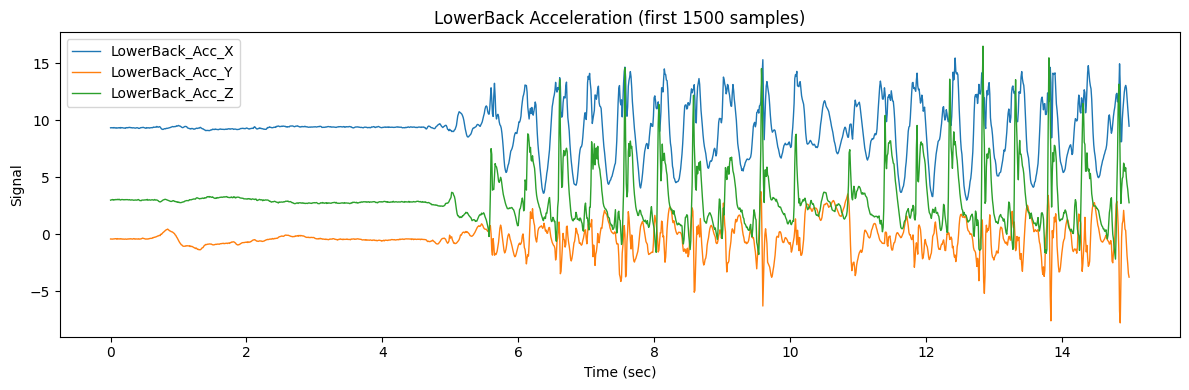

In [12]:
# Quick waveform visualization for one file
example = idx.iloc[0]
example_path = Path(example.file_path)
raw = pd.read_csv(example_path, low_memory=False)

t = pd.to_numeric(raw['Time'].astype(str).str.replace('sec', '', regex=False).str.strip(), errors='coerce')
channels_to_plot = [c for c in ['LowerBack_Acc_X', 'LowerBack_Acc_Y', 'LowerBack_Acc_Z'] if c in raw.columns]
plot_df = raw[channels_to_plot].apply(pd.to_numeric, errors='coerce').ffill().bfill()

print('Example file:', example_path.name)
print('Subject:', example.subject_id, '| Task:', example.task, '| Label:', example.label)

fig, ax = plt.subplots(figsize=(12, 4))
for c in channels_to_plot:
    ax.plot(t.values[:1500], plot_df[c].values[:1500], label=c, linewidth=1.0)
ax.set_title('LowerBack Acceleration (first 1500 samples)')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('Signal')
ax.legend()
plt.tight_layout()
plt.show()

## Next Checks You Can Add

- Per-task model-ready window counts after applying full channel checks
- Outlier detection for force/CoP channels
- Subject-level duration statistics by task
- PD vs HC signal summary plots for selected channels